In [19]:
# Import necessary libraries for data manipulation, model building, and evaluation
%matplotlib inline
from hmmlearn import hmm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
import scipy.stats as stats
import statsmodels.api as sm


## Load and Prepare

First we load in the functions and data we need. I pull from the NVO ticker


In [20]:
from modelFuncs import dataExtracterDays, HMMPricePredictor_pct

ticker = 'NVO'

obs = dataExtracterDays('NVO', '2025-01-01', '2026-01-01')
cutoff = 200
data = obs[:cutoff]
dates = obs['Date'][cutoff:]
data = data[data.columns[1:5]]
obs = obs[obs.columns[1:5]]

[*********************100%***********************]  1 of 1 completed

The dataset has observations across 250 days


This will train on 2025-01-01 to 2025-10-21 and test on 2025-10-21 to 2026-01-01

In [4]:
hmm_price, close, expected_pct_changes = HMMPricePredictor_pct(data, obs, window_size=96, Ncomp=5)

From the predictions we want to generate buy/sell signals. This is based on whether returns are above or below a threshold, and also on short- and long term exponential moving averages to identify trends. This is of course causal, so the function only knows about past prices, and the one-day-ahead predicted price.  

In [5]:
def GenerateSignals(obs, expected_pct_changes, threshold=0):
    signals = []
    last_pos = -1 #Start OUT 
    
    
    predict_size = len(expected_pct_changes)
    relevant_prices = obs['Close'].iloc[-predict_size-20:]
    
    fast_ema = relevant_prices.ewm(span=2, adjust=False).mean()
    slow_ema = relevant_prices.ewm(span=10, adjust=False).mean()


    for i in range(predict_size):
        #Match indices
        idx = i + 20 
        curr_p = relevant_prices.iloc[idx]
        f_ema = fast_ema.iloc[idx]
        s_ema = slow_ema.iloc[idx]
        expected_return = expected_pct_changes[i]


        is_bullish = expected_return > threshold or curr_p > f_ema 
        is_bearish = expected_return < -threshold and curr_p < s_ema

        # 1 = buy/hold
        # -1 = sell
        if last_pos <= 0:
            curr_sig = 1 if is_bullish else -1
        else:
            curr_sig = -1 if is_bearish else 1
            
        signals.append(curr_sig)
        last_pos = curr_sig
        
    return signals

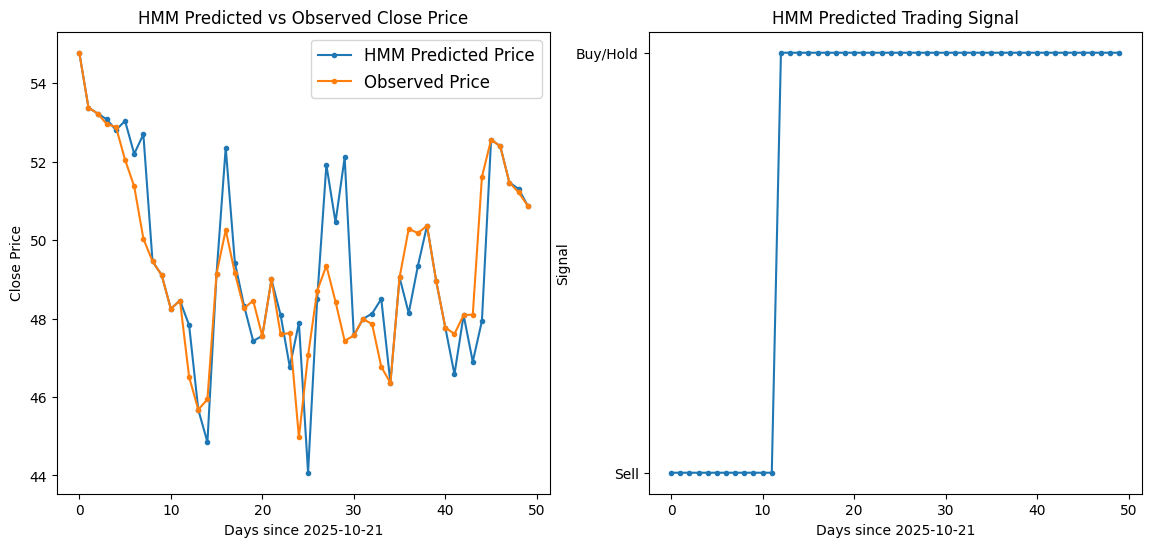

In [18]:
signals = GenerateSignals(obs, expected_pct_changes, 0.4)
fig, ax = plt.subplots(figsize=(14, 6), ncols = 2)
hmm_price_array = np.array(hmm_price)
ax[0].plot(hmm_price_array,marker='.', label = "HMM Predicted Price")
ax[0].plot(close,marker = '.', label= "Observed Price")
ax[0].set_ylabel("Close Price")
ax[0].set_xlabel("Days since 2025-10-21")
ax[0].set_title("HMM Predicted vs Observed Close Price")
ax[0].legend(fontsize=12)
ax[1].plot(signals,marker='.', label = "HMM Predicted Signal")
ax[1].set_ylabel("Signal")
ax[1].set_xlabel("Days since 2025-10-21")
ax[1].set_yticks([-1, 1], ['Sell', 'Buy/Hold'])
ax[1].set_title("HMM Predicted Trading Signal")
plt.show()

Now we translate the signal into a portfolio value based on a simple binary model (own 0 or 1 asset at any one time)

In [ ]:
def trading_strat(signals, close):
    """
    Simulate trading based on signals:
    - Buy/Hold = 1
    - Sell = -1

    Owns either 0 or 1 unit of stock at any time

    Returns:
        values: portfolio value at each step
        positions: 0 or 1 stock held at each step
    """
    n = len(signals)
    values = np.zeros(n)      # Portfolio value
    positions = np.zeros(n)   # 0 or 1 stock held

    stocks_owned = 0
    cash = 0

    for i in range(n):
        if signals[i] == 1:  #Buy/Hold
            if stocks_owned == 0:
                stocks_owned = 1
                cash -= close[i]  #Spend money to buy
        elif signals[i] == -1:  #Sell
            if stocks_owned == 1:
                stocks_owned = 0
                cash += close[i]  #Receive cash from selling

        positions[i] = stocks_owned
        values[i] = cash + stocks_owned * close[i]  # Total portfolio value

    return values, positions

values, positions = trading_strat(signals, close)

Plotting

In [15]:
def plot_trading_signals(hmm_price, close, signals, values):
    close = np.array(close)
    signals = np.array(signals)
    values = np.array(values)

    buy_indices = np.where(signals == 1)[0]
    sell_indices = np.where(signals == -1)[0]

    plt.figure(figsize=(8,6))
    
    #Plot close price
    plt.plot(close, label='Close Price', color='blue')
    values = values + close[0]  # Normalize portfolio value to start at the same point as price
    #Plot portfolio value
    plt.plot(values, label='Portfolio Value', color='green', linestyle='--')
    #Plot the predicted price
    plt.plot(hmm_price, label='Predicted Price', color='orange', linestyle='-.')
    
    #Plot buy/sell signals
    plt.scatter(buy_indices, close[buy_indices], marker='^', color='green', s=100, label='Buy Signal')
    plt.scatter(sell_indices, close[sell_indices], marker='v', color='red', s=100, label='Sell Signal')
    
    plt.title(f"HMM Trading Signals for {ticker}", fontsize=14)
    plt.xlabel("Days since 2025-10-21", fontsize=13)
    plt.ylabel("Price / Portfolio Value", fontsize=13)
    plt.legend(fontsize=12)
    plt.grid(True)
    plt.savefig('trading_signals.pdf')
    plt.show()

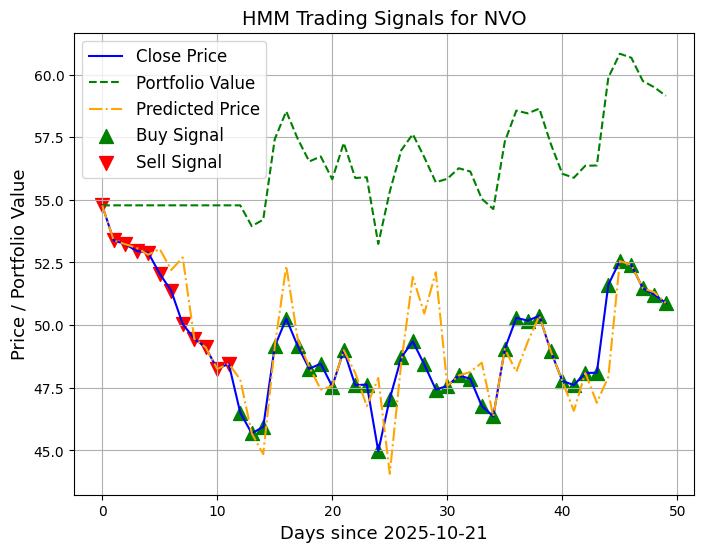

In [16]:
signals = GenerateSignals(obs, expected_pct_changes, 0.4)
values, positions = trading_strat(signals, close)
plot_trading_signals(hmm_price, close, signals, values)

The model is primitive and far from perfect, but the signals are good enough to be used for a viable trading strategy. It is the signal generation process that needs tweaking